In [1]:
from utils import *
from pyspark.sql.functions import *
from pyspark.sql.window import *

spark = instantiate_spark_sedona("10g")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/11 05:19:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/11 05:19:47 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/02/11 05:19:47 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/02/11 05:19:47 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/02/11 05:19:47 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


Spark Session and SedonaContext have been successfully initiated.


In [2]:

# pop_nso_hdx = spark.read.csv('Pop_Hdx_nso_province_level.csv', header=True).select(col('Province'), col('Population_hdx'), col('Population_nso'))
# pop_nso_hdx = pop_nso_hdx.withColumn('nso_to_hdx', col('Population_nso')/col('Population_hdx'))
# pop_nso_hdx_ratio = pop_nso_hdx.select(col('Province'), col('nso_to_hdx'))
# pop_nso_hdx_ratio.show()

In [3]:
hdx_pop_updated = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Population_filtered/Quadkey_wise_population_updated')
hdx_pop_updated_grouped = hdx_pop_updated.groupby(col('adm1_name')).agg(sum('Quadkey_Pop').alias('Population_hdx'))
hdx_pop_updated_grouped = hdx_pop_updated_grouped.withColumnRenamed('adm1_name', 'Province') \
                                                .withColumn('Province', lower(regexp_replace(col('Province'), " ", "")))
# hdx_pop_updated_grouped.show()
nso_pop = spark.read.csv('Pop_Hdx_nso_province_level.csv', header=True).select(col('Province'), col('Population_nso'))
pop_nso_hdx = hdx_pop_updated_grouped.join(
    nso_pop,
    on = 'Province',
    how = 'inner'
)
pop_nso_hdx = pop_nso_hdx.withColumn('nso_to_hdx', col('Population_nso')/col('Population_hdx'))
pop_nso_hdx_ratio = pop_nso_hdx.select(col('Province'), col('nso_to_hdx')).orderBy(col('Province'))
pop_nso_hdx_ratio.show()

+-------------+------------------+
|     Province|        nso_to_hdx|
+-------------+------------------+
| amnatcharoen|1.3095653425533569|
|     angthong| 1.081226552075764|
|      bangkok|0.9269929581391236|
|     buengkan|0.9521570338784875|
|      buriram|1.1407454243404298|
| chachoengsao|1.2118037067044642|
|      chainat|1.1339627116532995|
|   chaiyaphum|1.1140545771894914|
|  chanthaburi|1.2267853486669522|
|    chiangmai|0.9293976867167185|
|    chiangrai|0.9575711485948801|
|     chonburi| 0.937817197860718|
|     chumphon|1.0703176857977514|
|      kalasin|1.0216185913718576|
|kamphaengphet|0.8657910400290796|
| kanchanaburi|0.9869642783784914|
|     khonkaen|1.0225002642448116|
|        krabi|1.1262739836214066|
|      lampang| 1.029756244525863|
|      lamphun| 0.919863693742187|
+-------------+------------------+
only showing top 20 rows



In [4]:
quadtile_w_subdistrict = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/thailand_quadkeys_w_subdistrict')
quadtile_w_subdistrict = quadtile_w_subdistrict.withColumn('adm1_name', regexp_replace(lower(col('adm1_name')), " ", ""))
quadtile_w_subdistrict.show()

+----------------+--------------------+--------------------+-----------------+------------+---------+--------------------+
|         quadkey|    quadkey_geometry|    quadkey_centroid|        adm3_name|   adm2_name|adm1_name|            geometry|
+----------------+--------------------+--------------------+-----------------+------------+---------+--------------------+
|1322122012022123|POLYGON ((101.980...|POINT (101.983337...|Thung Mahacharoen|Wang Nam Yen|   sakaeo|POLYGON ((102.032...|
|1322122012022132|POLYGON ((101.986...|POINT (101.988830...|Thung Mahacharoen|Wang Nam Yen|   sakaeo|POLYGON ((102.032...|
|1322122012022133|POLYGON ((101.991...|POINT (101.994323...|Thung Mahacharoen|Wang Nam Yen|   sakaeo|POLYGON ((102.032...|
|1322122012023022|POLYGON ((101.997...|POINT (101.999816...|Thung Mahacharoen|Wang Nam Yen|   sakaeo|POLYGON ((102.032...|
|1322122012023023|POLYGON ((102.002...|POINT (102.005310...|Thung Mahacharoen|Wang Nam Yen|   sakaeo|POLYGON ((102.032...|
|132212201202302

In [5]:
quadtile_w_subdistrict = quadtile_w_subdistrict.join(
    pop_nso_hdx_ratio,
    quadtile_w_subdistrict.adm1_name == pop_nso_hdx_ratio.Province,
    "inner"
).select(
    col("quadkey"),
    col("adm1_name"),
    col("nso_to_hdx")
)

quadtile_w_subdistrict.show()


+----------------+---------+-----------------+
|         quadkey|adm1_name|       nso_to_hdx|
+----------------+---------+-----------------+
|1322122002333113| chonburi|0.937817197860718|
|1322122003222002| chonburi|0.937817197860718|
|1322122002333111| chonburi|0.937817197860718|
|1322122003222000| chonburi|0.937817197860718|
|1322122002331333| chonburi|0.937817197860718|
|1322122003220222| chonburi|0.937817197860718|
|1322122002331331| chonburi|0.937817197860718|
|1322122003220220| chonburi|0.937817197860718|
|1322122002331313| chonburi|0.937817197860718|
|1322122003220212| chonburi|0.937817197860718|
|1322122003220202| chonburi|0.937817197860718|
|1322122003220203| chonburi|0.937817197860718|
|1322122002331311| chonburi|0.937817197860718|
|1322122003220200| chonburi|0.937817197860718|
|1322122003220210| chonburi|0.937817197860718|
|1322122021012001| chonburi|0.937817197860718|
|1322122021012010| chonburi|0.937817197860718|
|1322122021012011| chonburi|0.937817197860718|
|132212202101

In [6]:
# pop_quadtile = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Population_filtered/thailand_population_quadkey_indexed.parquet')
# pop_quadtile = pop_quadtile.groupby(col('qk16')).agg(sum(col('tha_general_2020')).alias("Quadkey_Pop"))
pop_quadtile = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Population_filtered/Quadkey_wise_population_updated').select(
    col('quadkey'), 
    col('Quadkey_Pop')
)
pop_quadtile.show()

+----------------+------------------+
|         quadkey|       Quadkey_Pop|
+----------------+------------------+
|1322012131311203| 4.293133806451612|
|1322011320212133| 6.010475789473685|
|1322011322013310|          4.639466|
|1322011232320103|3.4119913846153844|
|1322213001131110| 7.654719272727272|
|1322213010202132| 5.658230499999999|
|1322013031021131|17.437455749999994|
|1322012131222312|          4.045242|
|1322012132033133|         8.8200492|
|1322012121231133|4.3577318181818185|
|1322120123100230|          2.047779|
|1322103222213331| 3.816822857142857|
|1322103222302300| 5.343552000000001|
|1322013111320302| 8.178126555555556|
|1322013112103002|          4.254174|
|1322013112332312|3.7826866666666663|
|1322102232012000|5.5095807812499995|
|1322102301110111| 8.152591090909088|
|1322011332223223|          1.865092|
|1322013110023200| 2.072324444444445|
+----------------+------------------+
only showing top 20 rows



In [7]:
pop_quadtile_nso_adjusted = quadtile_w_subdistrict.join(
    pop_quadtile,
    on = 'quadkey',
    how = "inner"
)
pop_quadtile_nso_adjusted = pop_quadtile_nso_adjusted.withColumn('nso_adjusted_population', col('nso_to_hdx')*col('Quadkey_Pop'))
pop_quadtile_nso_adjusted.count() # population present only for 775799 quadtiles, 981682 now

981682

In [8]:
pop_quadtile_nso_adjusted.show()

+----------------+---------+-----------------+------------------+-----------------------+
|         quadkey|adm1_name|       nso_to_hdx|       Quadkey_Pop|nso_adjusted_population|
+----------------+---------+-----------------+------------------+-----------------------+
|1322122003222002| chonburi|0.937817197860718| 39.89299599999999|      37.41233772298882|
|1322122002333111| chonburi|0.937817197860718|12.629983999999999|     11.844616203905701|
|1322122003222000| chonburi|0.937817197860718|30.686919999999994|      28.77872132537602|
|1322122002331333| chonburi|0.937817197860718|          9.206076|      8.633616397612807|
|1322122003220222| chonburi|0.937817197860718|         12.274768|      11.51148853015041|
|1322122002331331| chonburi|0.937817197860718|          3.068692|     2.8778721325376027|
|1322122003220220| chonburi|0.937817197860718|         12.274768|      11.51148853015041|
|1322122003220212| chonburi|0.937817197860718| 85.92337599999998|      80.58041971105285|
|132212200

In [9]:
pop_quadtile_nso_adjusted.select(sum(col('nso_adjusted_population'))).show()

+----------------------------+
|sum(nso_adjusted_population)|
+----------------------------+
|         7.017988999999806E7|
+----------------------------+



In [10]:
quadkey_buil_floor_area = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Gee_Buildings/quadkey_buildings_metric.parquet")
quadkey_buil_floor_area.count()

pop_quadtile_nso_adjusted_w_buildings = pop_quadtile_nso_adjusted.join(
    quadkey_buil_floor_area,
    on = 'quadkey',
    how = 'inner'
).select(pop_quadtile_nso_adjusted['*'], quadkey_buil_floor_area.sum_floor_area_sqm)
pop_quadtile_nso_adjusted_w_buildings.count()

981682

In [11]:
province_to_quadkey_count = pop_quadtile_nso_adjusted_w_buildings.groupBy(col('adm1_name')).agg(count(col('quadkey')).alias('quadkeys_count'))
province_to_quadkey_count.persist()
province_to_quadkey_count.show()

+------------+--------------+
|   adm1_name|quadkeys_count|
+------------+--------------+
|     lampang|         15968|
|    chumphon|         13219|
|  narathiwat|          6888|
|mahasarakham|         15141|
| nakhonsawan|         18798|
|        trat|          5735|
| sakonnakhon|         24117|
| phitsanulok|         18237|
|  suphanburi|         12945|
|    singburi|          2022|
|    mukdahan|          9058|
|        loei|         22418|
|     pattani|          4226|
|    yasothon|         10466|
|  ratchaburi|         10067|
|       satun|          3963|
|     bangkok|          4432|
|    buengkan|         10024|
|nakhonpathom|          6001|
|amnatcharoen|          8869|
+------------+--------------+
only showing top 20 rows



In [12]:
province_to_quadkey_count.count()

77

In [13]:
pop_quadtile.count(), quadkey_buil_floor_area.count()

(981682, 981705)

In [2]:
import pandas as pd
pop_to_hh = pd.read_csv('pop_hhcount_nso_w_geom.csv')
pop_to_hh

,Province,Population_2021,2022_HH_count,geometry,Pop_to_HH
0,bangkok,9102272,3369140,POLYGON ((100.91398311800003 13.94649089400002...,2.701660
1,samutprakan,2396310,924779,POLYGON ((100.86076681300005 13.69690340900007...,2.591224
2,nonthaburi,1889277,608941,POLYGON ((100.56754835800007 13.95120327700004...,3.102562
3,pathumthani,1889029,675573,POLYGON ((100.95111814600006 14.27168420700002...,2.796188
4,phranakhonsiayutthaya,920073,311101,POLYGON ((100.60228489700006 14.65505073300005...,2.957474
...,...,...,...,...,...
72,trang,634266,194527,"POLYGON ((99.73824742400006 7.858896272000038,...",3.260555
73,phatthalung,491159,158711,POLYGON ((100.17749518400007 7.876479127000039...,3.094675
74,pattani,652332,152469,POLYGON ((101.72484185400003 6.576857325000049...,4.278457
75,yala,485872,135391,"POLYGON ((101.59243153100005 6.56560236200005,...",3.588658


In [14]:
import pandas as pd
pop_to_hh = pd.read_csv('pop_hhcount_nso_w_geom.csv')
pop_to_hh = pop_to_hh[['Province', 'Population_2021', '2022_HH_count', 'Pop_to_HH']]
pop_to_hh['Pop_to_HH'] = pop_to_hh['Pop_to_HH'].round(2)
pop_to_hh.describe()

,Population_2021,2022_HH_count,Pop_to_HH
count,7.700000e+01,7.700000e+01,77.000000
mean,9.114271e+05,3.062050e+05,3.059870
std,1.080746e+06,3.971657e+05,0.290714
min,1.743250e+05,5.843900e+04,2.590000
25%,4.358950e+05,1.397310e+05,2.880000
50%,6.814700e+05,2.129760e+05,3.050000
75%,1.025206e+06,3.237840e+05,3.200000
max,9.102272e+06,3.369140e+06,4.280000


In [15]:
from pyspark.sql.functions import col

In [16]:
pop_to_hh_spark = spark.createDataFrame(pop_to_hh)
pop_to_hh_spark = pop_to_hh_spark.withColumn("Pop_to_HH_u_limit", round(col('Pop_to_HH')+3*lit(0.29), 2)) \
                                .withColumn("Pop_to_HH_l_limit", round(col('Pop_to_HH')-3*lit(0.29), 2)) \
                                .withColumn("Province", lower(col('Province')))
pop_to_hh_spark.show()

+--------------------+---------------+-------------+---------+-----------------+-----------------+
|            Province|Population_2021|2022_HH_count|Pop_to_HH|Pop_to_HH_u_limit|Pop_to_HH_l_limit|
+--------------------+---------------+-------------+---------+-----------------+-----------------+
|             bangkok|        9102272|      3369140|      2.7|             3.57|             1.83|
|         samutprakan|        2396310|       924779|     2.59|             3.46|             1.72|
|          nonthaburi|        1889277|       608941|      3.1|             3.97|             2.23|
|         pathumthani|        1889029|       675573|      2.8|             3.67|             1.93|
|phranakhonsiayutt...|         920073|       311101|     2.96|             3.83|             2.09|
|            angthong|         242466|        82287|     2.95|             3.82|             2.08|
|             lopburi|         768859|       266958|     2.88|             3.75|             2.01|
|         

In [17]:
pop_to_hh_spark_join = pop_to_hh_spark.join(
    province_to_quadkey_count,
    pop_to_hh_spark.Province == province_to_quadkey_count.adm1_name,
    "inner"
).drop(col('adm1_name'))
pop_to_hh_spark_join.show() #77

+--------------------+---------------+-------------+---------+-----------------+-----------------+--------------+
|            Province|Population_2021|2022_HH_count|Pop_to_HH|Pop_to_HH_u_limit|Pop_to_HH_l_limit|quadkeys_count|
+--------------------+---------------+-------------+---------+-----------------+-----------------+--------------+
|             bangkok|        9102272|      3369140|      2.7|             3.57|             1.83|          4432|
|         samutprakan|        2396310|       924779|     2.59|             3.46|             1.72|          2664|
|          nonthaburi|        1889277|       608941|      3.1|             3.97|             2.23|          1809|
|         pathumthani|        1889029|       675573|      2.8|             3.67|             1.93|          4264|
|phranakhonsiayutt...|         920073|       311101|     2.96|             3.83|             2.09|          6445|
|            angthong|         242466|        82287|     2.95|             3.82|        

In [18]:
import random

def gaussian_bounded_samples(lower, upper, n, seed):
    random.seed(seed)

    mu = (lower + upper) / 2
    sigma = (upper - lower) / 6

    samples = []
    while len(samples) < n:
        v = random.gauss(mu, sigma)
        if lower <= v <= upper:
            samples.append(v)

    return sorted(samples)

In [19]:
province_params = pop_to_hh_spark_join.select(
        "Province",
        "Pop_to_HH_l_limit",
        "Pop_to_HH_u_limit",
        "quadkeys_count"
    ).collect()

dfs = []

for idx, row in enumerate(province_params, start=1):
    province = row["Province"]
    lower = row["Pop_to_HH_l_limit"]
    upper = row["Pop_to_HH_u_limit"]
    n = int(row["quadkeys_count"])

    samples = gaussian_bounded_samples(
        lower=lower,
        upper=upper,
        n=n,
        seed=idx     # seed = 1 to 77
    )

    pdf = spark.createDataFrame(
        [(province, v) for v in samples],
        ["Province", "Qk_pop_to_hh"]
    )

    dfs.append(pdf)


In [20]:
from functools import reduce

final_pop_to_hh_df = reduce(
    lambda a, b: a.unionByName(b),
    dfs
).orderBy(col('Province'), col('Qk_pop_to_hh'))
final_pop_to_hh_df.persist()

DataFrame[Province: string, Qk_pop_to_hh: double]

In [21]:
final_pop_to_hh_df

DataFrame[Province: string, Qk_pop_to_hh: double]

In [22]:
pop_quadtile_nso_adjusted_w_buildings.count()

981682

In [23]:
pop_quadtile_nso_adjusted_w_buildings.show()

+----------------+----------+-----------------+------------------+-----------------------+------------------+
|         quadkey| adm1_name|       nso_to_hdx|       Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|
+----------------+----------+-----------------+------------------+-----------------------+------------------+
|1322010330330112|maehongson|1.156384169474568|         3.3361215|       3.85783809004375|120.31849027728747|
|1322010331201320|maehongson|1.156384169474568|1.8587143333333334|      2.149387830642142|17.154244963232237|
|1322010331201323|maehongson|1.156384169474568| 2.706338181818182|     3.1295666306991308|192.72464318952922|
|1322010331202200|maehongson|1.156384169474568|          7.938592|       9.18006211671745| 1561.648755833432|
|1322010331202212|maehongson|1.156384169474568|         3.7708312|      4.360529505440788|255.54815445934742|
|1322010331222012|maehongson|1.156384169474568|2.6719926363636364|      3.089849985643525| 35.54481692685274|
|132201033

In [24]:
window1 = Window.partitionBy(col('Province')).orderBy(col('Qk_pop_to_hh'))
window2 = Window.partitionBy(col('adm1_name')).orderBy(col('sum_floor_area_sqm').desc())

final_pop_to_hh_df = final_pop_to_hh_df.withColumn('rank', row_number().over(window1))
pop_quadtile_nso_adjusted_w_buildings = pop_quadtile_nso_adjusted_w_buildings.withColumn('rank', row_number().over(window2))

In [25]:
pop_quadtile_nso_adjusted_w_buildings.show()

+----------------+---------+------------------+------------------+-----------------------+------------------+----+
|         quadkey|adm1_name|        nso_to_hdx|       Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|rank|
+----------------+---------+------------------+------------------+-----------------------+------------------+----+
|1322211012222331| chumphon|1.0703176857977514| 638.4418039999957|      683.3355541738171| 342115.2952147268|   1|
|1322211012222330| chumphon|1.0703176857977514| 631.7448619999958|      676.1676987104554|  312621.098924736|   2|
|1322211012222312| chumphon|1.0703176857977514| 569.2400699999965|      609.2677143857463| 283008.4402011315|   3|
|1322211012222313| chumphon|1.0703176857977514| 649.6033739999956|      695.2819799460865|277292.54863459454|   4|
|1322211023310122| chumphon|1.0703176857977514| 558.5891999999976|      597.8678998556148| 266098.7498417849|   5|
|1322211023310033| chumphon|1.0703176857977514| 635.9323199999972|       680.649

In [26]:
final_pop_to_hh_df.show()

+--------+------------------+----+
|Province|      Qk_pop_to_hh|rank|
+--------+------------------+----+
|chumphon| 2.091234058800673|   1|
|chumphon|2.0934184623722714|   2|
|chumphon| 2.095667417620245|   3|
|chumphon|2.0985141343633043|   4|
|chumphon| 2.114106351770004|   5|
|chumphon|2.1160914713212513|   6|
|chumphon| 2.116494462211189|   7|
|chumphon|2.1202342395484988|   8|
|chumphon| 2.120900936886674|   9|
|chumphon| 2.121735203579691|  10|
|chumphon| 2.122706280638427|  11|
|chumphon|  2.12296552270804|  12|
|chumphon|2.1237068144606766|  13|
|chumphon| 2.124500323270196|  14|
|chumphon|2.1299101180248323|  15|
|chumphon|2.1316393145107213|  16|
|chumphon|2.1347451706596696|  17|
|chumphon|2.1348124226476632|  18|
|chumphon| 2.147167715338762|  19|
|chumphon|2.1485258869020143|  20|
+--------+------------------+----+
only showing top 20 rows



In [27]:

final_df = pop_quadtile_nso_adjusted_w_buildings.alias("b").join(
    final_pop_to_hh_df.alias("a"),
    (col("a.Province") == col("b.adm1_name")) &
    (col("a.rank") == col("b.rank")),
    "inner"
).drop(col("a.Province"), col("a.rank"), col("b.rank"))

final_df.count()


981682

In [28]:
final_df.show()

+----------------+------------+------------------+------------------+-----------------------+------------------+------------------+
|         quadkey|   adm1_name|        nso_to_hdx|       Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|      Qk_pop_to_hh|
+----------------+------------+------------------+------------------+-----------------------+------------------+------------------+
|1322121021120132|amnatcharoen|1.3095653425533569| 360.5164419999983|      472.1198378638452|164002.90531904236| 2.336591790030724|
|1322121003323002|amnatcharoen|1.3095653425533569| 143.7023580000002|      188.1876276799954|  74279.4457615968|2.4562155699841672|
|1322121032010130|amnatcharoen|1.3095653425533569|242.10516399999943|     317.05253202759593| 63943.39575970446| 2.478820311544628|
|1322121021120122|amnatcharoen|1.3095653425533569|216.81408400000035|     283.93221018385276|59503.034681355784|2.5005976446036717|
|1322121021121011|amnatcharoen|1.3095653425533569|283.62307499999986|     37

In [29]:
final_df = final_df.withColumn("Qk_estimated_hh", round(col('nso_adjusted_population')/col('Qk_pop_to_hh'), 0))

In [30]:
final_df.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- nso_to_hdx: double (nullable = true)
 |-- Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)



In [31]:
final_df.show(5)

+----------------+------------+------------------+------------------+-----------------------+------------------+------------------+---------------+
|         quadkey|   adm1_name|        nso_to_hdx|       Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|      Qk_pop_to_hh|Qk_estimated_hh|
+----------------+------------+------------------+------------------+-----------------------+------------------+------------------+---------------+
|1322121021120132|amnatcharoen|1.3095653425533569| 360.5164419999983|      472.1198378638452|164002.90531904236| 2.336591790030724|          202.0|
|1322121003323002|amnatcharoen|1.3095653425533569| 143.7023580000002|      188.1876276799954|  74279.4457615968|2.4562155699841672|           77.0|
|1322121032010130|amnatcharoen|1.3095653425533569|242.10516399999943|     317.05253202759593| 63943.39575970446| 2.478820311544628|          128.0|
|1322121021120122|amnatcharoen|1.3095653425533569|216.81408400000035|     283.93221018385276|59503.034681355784|

In [32]:
estimated_province_level_hh = final_df.groupBy(col('adm1_name')).agg(sum('Qk_estimated_hh').alias('est_hh_count'))
estimated_province_level_hh.show()

+------------+------------+
|   adm1_name|est_hh_count|
+------------+------------+
|    chumphon|    190037.0|
|     lampang|    309455.0|
|  narathiwat|    197987.0|
|mahasarakham|    309812.0|
| nakhonsawan|    373653.0|
|        trat|    110141.0|
| sakonnakhon|    310770.0|
| phitsanulok|    382136.0|
|  suphanburi|    315925.0|
|    singburi|     69062.0|
|    mukdahan|    150874.0|
|        loei|    185906.0|
|     pattani|    163847.0|
|    yasothon|    154899.0|
|  ratchaburi|    277886.0|
|       satun|     93328.0|
|     bangkok|   3675533.0|
|    buengkan|    116533.0|
|nakhonpathom|    452484.0|
|amnatcharoen|    100874.0|
+------------+------------+
only showing top 20 rows



In [33]:
pop_to_hh_spark.show()

+--------------------+---------------+-------------+---------+-----------------+-----------------+
|            Province|Population_2021|2022_HH_count|Pop_to_HH|Pop_to_HH_u_limit|Pop_to_HH_l_limit|
+--------------------+---------------+-------------+---------+-----------------+-----------------+
|             bangkok|        9102272|      3369140|      2.7|             3.57|             1.83|
|         samutprakan|        2396310|       924779|     2.59|             3.46|             1.72|
|          nonthaburi|        1889277|       608941|      3.1|             3.97|             2.23|
|         pathumthani|        1889029|       675573|      2.8|             3.67|             1.93|
|phranakhonsiayutt...|         920073|       311101|     2.96|             3.83|             2.09|
|            angthong|         242466|        82287|     2.95|             3.82|             2.08|
|             lopburi|         768859|       266958|     2.88|             3.75|             2.01|
|         

In [34]:
hh_comparison = estimated_province_level_hh.alias("a").join(
    pop_to_hh_spark.select(col('Province'), col('2022_HH_count')).alias("b"),
    col('a.adm1_name') == col('b.Province'),
    "inner"
).drop(col('Province'))
hh_comparison.count()

77

In [35]:
hh_comparison = hh_comparison.withColumn('% diff', abs((col('est_hh_count') - col('2022_HH_count'))) * 100/ col('2022_HH_count'))
hh_comparison.orderBy(col('% diff').desc()).show()

+------------+------------+-------------+------------------+
|   adm1_name|est_hh_count|2022_HH_count|            % diff|
+------------+------------+-------------+------------------+
|       phrae|    162976.0|       134491|21.179855901138367|
|   chiangmai|    795027.0|       663111| 19.89350199287902|
|      phayao|    157667.0|       131833|19.596004035408434|
|     lampang|    309455.0|       259251|19.365016914110264|
|         nan|    177072.0|       149978|18.065316246382803|
| phitsanulok|    382136.0|       323784| 18.02189113730141|
|     lamphun|    173852.0|       148181|17.324083384509485|
|  maehongson|     95774.0|        81739| 17.17050612314807|
|   uttaradit|    162803.0|       139770|16.479215854618303|
|    khonkaen|    682121.0|       586961| 16.21232075044168|
|   sukhothai|    244411.0|       210828|15.929098601703759|
|  chaiyaphum|    346450.0|       298996| 15.87111533264659|
| nakhonsawan|    373653.0|       322883| 15.72396193048256|
|   chiangrai|    431933

In [36]:
hh_comparison_pd = hh_comparison.toPandas()
hh_comparison_pd.describe()

,est_hh_count,2022_HH_count,% diff
count,7.700000e+01,7.700000e+01,77.000000
mean,3.452103e+05,3.062050e+05,13.412872
std,4.352722e+05,3.971657e+05,2.747061
min,6.416100e+04,5.843900e+04,7.462501
25%,1.628030e+05,1.397310e+05,11.422533
50%,2.444110e+05,2.129760e+05,13.464514
75%,3.736530e+05,3.237840e+05,15.147070
max,3.675533e+06,3.369140e+06,21.179856


In [37]:
# hh_comparison_pd.to_csv('hh_comparison_pd.csv',index=False)


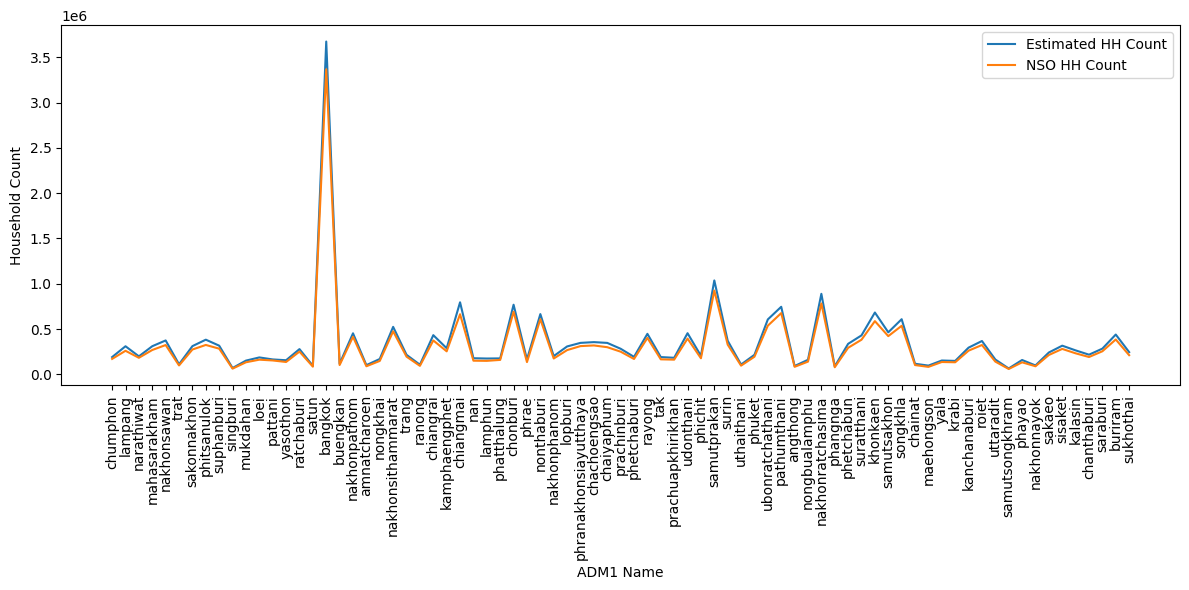

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    hh_comparison_pd["adm1_name"],
    hh_comparison_pd["est_hh_count"],
    label="Estimated HH Count"
)

plt.plot(
    hh_comparison_pd["adm1_name"],
    hh_comparison_pd["2022_HH_count"],
    label="NSO HH Count"
)

plt.xlabel("ADM1 Name")
plt.ylabel("Household Count")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
pop_to_hh['Population_2021'].sum()

70179890

In [40]:
pop_quadtile_nso_adjusted.select(sum(col('nso_adjusted_population'))).show()

+----------------------------+
|sum(nso_adjusted_population)|
+----------------------------+
|         7.017988999999806E7|
+----------------------------+



In [41]:
final_df.count()

981682

In [42]:
final_df.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- nso_to_hdx: double (nullable = true)
 |-- Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)



In [43]:
final_df = final_df.withColumnRenamed("nso_to_hdx", "Pop_nso_to_hdx_ratio") \
                    .withColumnRenamed("Quadkey_Pop", "hdx_Quadkey_Pop") \
                    .withColumnRenamed("Qk_pop_to_hh", "Qk_pop_to_hh_sampled")
# final_df.write.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/Quadkey_pop_hh_estimated")

In [ ]:
# final_df.write.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/Quadkey_pop_hh_estimated_updated")

In [ ]:
from pyspark.sql.functions import col

pdf = final_df.filter(
    (col("adm1_name") == "bangkok") |
    (col("adm1_name") == "nakhonratchasima") |
    (col("adm1_name") == "chiangmai")
).toPandas()

In [ ]:
pdf['sum_floor_area_sqm(%)'] = pdf['sum_floor_area_sqm']/360000

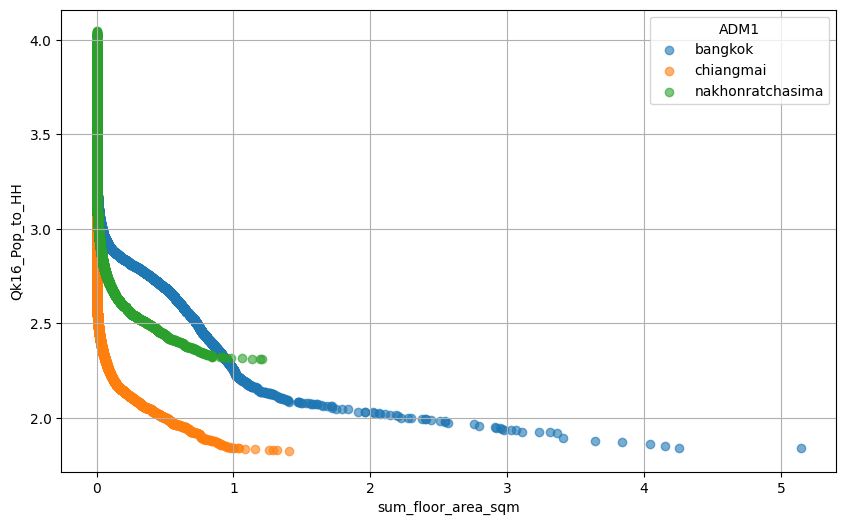

In [ ]:

plt.figure(figsize=(10, 6))

for adm1 in pdf["adm1_name"].unique():
    subset = pdf[pdf["adm1_name"] == adm1]
    plt.scatter(
        subset["sum_floor_area_sqm(%)"],
        subset["Qk_pop_to_hh_sampled"],
        label=adm1,
        alpha=0.6
    )

plt.xlabel("sum_floor_area_sqm")
plt.ylabel("Qk16_Pop_to_HH")
plt.legend(title="ADM1")
plt.grid(True)
plt.show()

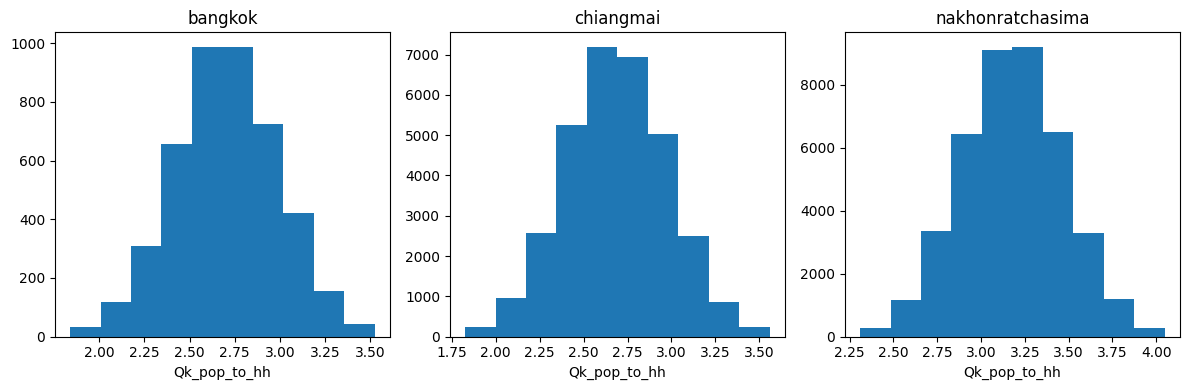

In [ ]:
adm_list = pdf["adm1_name"].unique()

plt.figure(figsize=(12, 4))

for i, adm in enumerate(adm_list, 1):
    plt.subplot(1, len(adm_list), i)
    plt.hist(
        pdf[pdf["adm1_name"] == adm]["Qk_pop_to_hh_sampled"],
        bins=10
    )
    plt.title(adm)
    plt.xlabel("Qk_pop_to_hh")

plt.tight_layout()
plt.show()


In [ ]:
pop_nso_hdx_pd = pop_nso_hdx.toPandas()
pop_nso_hdx_pd

,Province,Population_hdx,Population_nso,nso_to_hdx
0,chachoengsao,7.784924e+05,943380,1.211804
1,phitsanulok,1.011577e+06,891208,0.881009
2,sakonnakhon,8.176988e+05,902671,1.103916
3,phranakhonsiayutthaya,7.040580e+05,920073,1.306814
4,lampang,6.630657e+05,682796,1.029756
...,...,...,...,...
72,kanchanaburi,8.449424e+05,833928,0.986964
73,rayong,1.208742e+06,1144396,0.946767
74,singburi,1.414880e+05,182009,1.286392
75,udonthani,1.089928e+06,1241319,1.138900


In [ ]:
pop_to_hh.sort_values(by='Pop_to_HH', ascending=False)

,Province,Population_2021,2022_HH_count,Pop_to_HH
74,pattani,652332,152469,4.28
76,narathiwat,742463,181888,4.08
75,yala,485872,135391,3.59
71,satun,302059,84167,3.59
51,buengkan,354648,102007,3.48
...,...,...,...,...
30,phrae,358157,134491,2.66
28,lampang,682796,259251,2.63
22,samutsakhon,1107474,421295,2.63
27,lamphun,385308,148181,2.60


<Axes: >

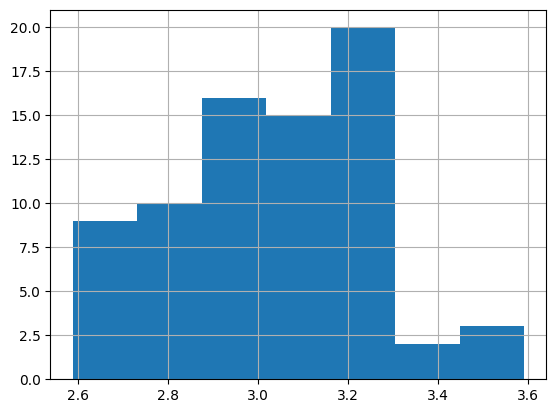

In [ ]:
pop_to_hh[pop_to_hh['Pop_to_HH'] < 4]['Pop_to_HH'].hist(bins = 7)

## Adjusting to reduce the error

In [44]:
final_df = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/Quadkey_pop_hh_estimated_updated")
final_df.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- Pop_nso_to_hdx_ratio: double (nullable = true)
 |-- hdx_Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh_sampled: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)



In [45]:
hh_comparison_pd

,adm1_name,est_hh_count,2022_HH_count,% diff
0,chumphon,190037.0,169702,11.982770
1,lampang,309455.0,259251,19.365017
2,narathiwat,197987.0,181888,8.851051
3,mahasarakham,309812.0,268086,15.564408
4,nakhonsawan,373653.0,322883,15.723962
...,...,...,...,...
72,kalasin,263778.0,231333,14.025236
73,chanthaburi,216294.0,190627,13.464514
74,saraburi,283160.0,253998,11.481193
75,buriram,438792.0,384119,14.233350


In [47]:
hh_comparison_pd[hh_comparison_pd['adm1_name'] == 'bangkok']

,adm1_name,est_hh_count,2022_HH_count,% diff
16,bangkok,3675533.0,3369140,9.094101


In [ ]:
intermediate_df = final_df.join(
    hh_comparison.select(col('adm1_name'), col('2022_HH_count'), col('est_hh_count')),
    on="adm1_name",
    how = "inner"
).drop(col('hh_comparison_pd.adm1_name'))
intermediate_df.count()

981682

In [ ]:
intermediate_df.printSchema()

root
 |-- adm1_name: string (nullable = true)
 |-- quadkey: string (nullable = true)
 |-- Pop_nso_to_hdx_ratio: double (nullable = true)
 |-- hdx_Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh_sampled: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)
 |-- 2022_HH_count: long (nullable = true)
 |-- est_hh_count: double (nullable = true)



In [ ]:
from pyspark.sql.window import Window

w = Window.partitionBy(col('adm1_name'))

intermediate_df = intermediate_df.withColumn("Province_levek_Hh_est", sum(col('Qk_estimated_hh')).over(w))

intermediate_df.show()


[Stage 725:=================================================>       (7 + 1) / 8]

+---------+----------------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+-------------+------------+---------------------+
|adm1_name|         quadkey|Pop_nso_to_hdx_ratio|   hdx_Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|Qk_pop_to_hh_sampled|Qk_estimated_hh|2022_HH_count|est_hh_count|Province_levek_Hh_est|
+---------+----------------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+-------------+------------+---------------------+
| chumphon|1322211012223222|  1.0703176857977514| 575.9370119999965|       616.435569849108| 219366.0170895094|   2.122706280638427|          290.0|       169702|    190037.0|             190037.0|
| chumphon|1322211012222333|  1.0703176857977514| 522.3614759999971|      559.0927261422146|184219.97439211787|  2.1299101180248323|          262.0|       169702|    190037.0|             190037.0|
| chumphon

In [ ]:
intermediate_df = intermediate_df.withColumn('Qk_estimated_hh_corrected',  round(col('Qk_estimated_hh') * col('2022_HH_count')/col('est_hh_count'), 0))
intermediate_df = intermediate_df.withColumn('Qk_pop_to_hh_corrected',  col('nso_adjusted_population')/col('Qk_estimated_hh_corrected'))
intermediate_df.printSchema()

root
 |-- adm1_name: string (nullable = true)
 |-- quadkey: string (nullable = true)
 |-- Pop_nso_to_hdx_ratio: double (nullable = true)
 |-- hdx_Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh_sampled: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)
 |-- 2022_HH_count: long (nullable = true)
 |-- est_hh_count: double (nullable = true)
 |-- Province_levek_Hh_est: double (nullable = true)
 |-- Qk_estimated_hh_corrected: double (nullable = true)
 |-- Qk_pop_to_hh_corrected: double (nullable = true)



## comparing to calculate error

In [ ]:
hh_comparison_recomputed = intermediate_df.groupBy(col('adm1_name')).agg(
    sum(col('Qk_estimated_hh_corrected')).alias("est_hh_count_corrected"),
    max(col('2022_HH_count')).alias("2022_HH_count")
)
hh_comparison_recomputed = hh_comparison_recomputed.withColumn('% diff', abs(col('est_hh_count_corrected') - col('2022_HH_count'))*100/col('2022_HH_count'))
hh_comparison_recomputed.show()

[Stage 775:=================================================>       (7 + 1) / 8]

+-----------------+----------------------+-------------+--------------------+
|        adm1_name|est_hh_count_corrected|2022_HH_count|              % diff|
+-----------------+----------------------+-------------+--------------------+
|     amnatcharoen|               89429.0|        88341|   1.231591220384646|
|          bangkok|             3369087.0|      3369140|0.001573101741097...|
|         buengkan|              103404.0|       102007|   1.369513856892174|
|         chumphon|              170477.0|       169702|  0.4566828911857256|
|          lampang|              261273.0|       259251|  0.7799391323466448|
|             loei|              163328.0|       161187|  1.3282708903323468|
|     mahasarakham|              268875.0|       268086|  0.2943085427810479|
|         mukdahan|              133470.0|       132432|   0.783798477709315|
|     nakhonpathom|              414370.0|       414358|0.002896046413970...|
|      nakhonsawan|              324190.0|       322883|   0.404

In [ ]:
hh_comparison_recomputed.toPandas()['% diff'].describe()

count    77.000000
mean      0.457726
std       0.368273
min       0.000821
25%       0.199584
50%       0.423520
75%       0.634792
max       1.766599
Name: % diff, dtype: float64

In [ ]:
pdf2 = intermediate_df.filter(
    (col("adm1_name") == "bangkok") |
    (col("adm1_name") == "nakhonratchasima") |
    (col("adm1_name") == "chiangmai")
).toPandas()


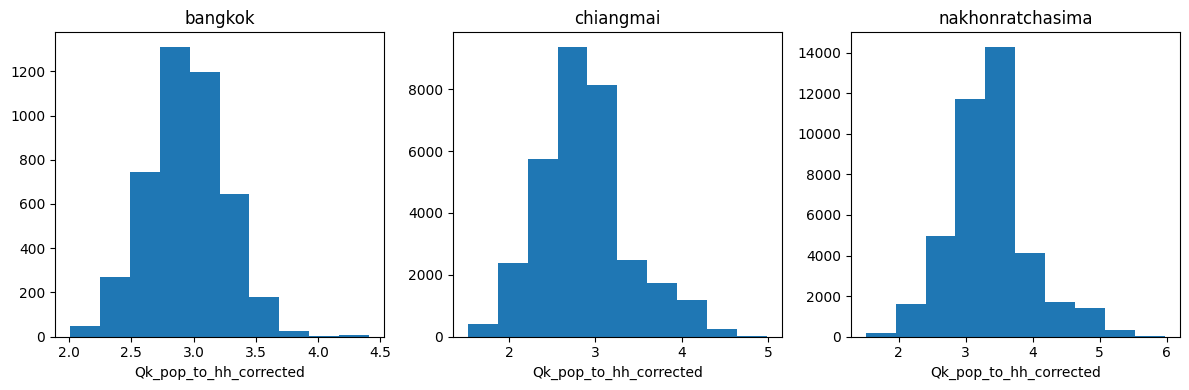

In [ ]:
import matplotlib.pyplot as plt
adm_list = pdf2["adm1_name"].unique()

plt.figure(figsize=(12, 4))

for i, adm in enumerate(adm_list, 1):
    plt.subplot(1, len(adm_list), i)
    plt.hist(
        pdf2[pdf2["adm1_name"] == adm]["Qk_pop_to_hh_corrected"],
        bins=10
    )
    plt.title(adm)
    plt.xlabel("Qk_pop_to_hh_corrected")

plt.tight_layout()
plt.show()


## plottable

In [ ]:
intermediate_df.printSchema()

root
 |-- adm1_name: string (nullable = true)
 |-- quadkey: string (nullable = true)
 |-- Pop_nso_to_hdx_ratio: double (nullable = true)
 |-- hdx_Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh_sampled: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)
 |-- 2022_HH_count: long (nullable = true)
 |-- est_hh_count: double (nullable = true)
 |-- Province_levek_Hh_est: double (nullable = true)
 |-- Qk_estimated_hh_corrected: double (nullable = true)
 |-- Qk_pop_to_hh_corrected: double (nullable = true)



In [ ]:
three_provinces_plt = intermediate_df.filter(
    (col("adm1_name") == "bangkok") |
    (col("adm1_name") == "nakhonratchasima") |
    (col("adm1_name") == "chiangmai")
).select(col('adm1_name'), col('quadkey'), col('nso_adjusted_population'), col('Qk_estimated_hh_corrected'), round(col('Qk_pop_to_hh_corrected'),2).alias('Qk_pop_to_hh_corrected'))

three_provinces_plt.show()

+---------+----------------+-----------------------+-------------------------+----------------------+
|adm1_name|         quadkey|nso_adjusted_population|Qk_estimated_hh_corrected|Qk_pop_to_hh_corrected|
+---------+----------------+-----------------------+-------------------------+----------------------+
|  bangkok|1322033110200303|      5282.587789744207|                   2367.0|                  2.23|
|  bangkok|1322033110202200|     3927.2716903758624|                   1735.0|                  2.26|
|  bangkok|1322033110021212|      3554.384079599058|                   1495.0|                  2.38|
|  bangkok|1322033110200103|      4892.012572101531|                   2032.0|                  2.41|
|  bangkok|1322033110022011|       8372.06828077974|                   3460.0|                  2.42|
|  bangkok|1322033110021210|     3621.0287810915406|                   1479.0|                  2.45|
|  bangkok|1322033110020333|      6135.314618977731|                   2403.0|    

In [ ]:
three_provinces_plt.count()

77030

In [ ]:
quadtile_w_subdistrict = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/thailand_quadkeys_w_subdistrict')
quadtile_w_subdistrict.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- quadkey_geometry: geometry (nullable = true)
 |-- quadkey_centroid: geometry (nullable = true)
 |-- adm3_name: string (nullable = true)
 |-- adm2_name: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- geometry: geometry (nullable = true)



In [ ]:
three_provinces_plt_w_qgeom = three_provinces_plt.drop('adm1_name').join(
    quadtile_w_subdistrict.select(col('quadkey'), col('quadkey_geometry'), col('adm1_name')),
    on = "quadkey",
    how = 'inner'
)
three_provinces_plt_w_qgeom.show()

+----------------+-----------------------+-------------------------+----------------------+--------------------+----------+
|         quadkey|nso_adjusted_population|Qk_estimated_hh_corrected|Qk_pop_to_hh_corrected|    quadkey_geometry| adm1_name|
+----------------+-----------------------+-------------------------+----------------------+--------------------+----------+
|1322011230001233|     103.93361019025326|                     37.0|                  2.81|POLYGON ((99.2010...|Chiang Mai|
|1322011230002001|       6.56146528978871|                      2.0|                  3.28|POLYGON ((99.1461...|Chiang Mai|
|1322011212212211|      5.335930491997589|                      2.0|                  2.67|POLYGON ((99.2449...|Chiang Mai|
|1322011230010110|      34.68354819798432|                     12.0|                  2.89|POLYGON ((99.2614...|Chiang Mai|
|1322011212220321|      24.01168721398915|                      8.0|                   3.0|POLYGON ((99.1680...|Chiang Mai|
|1322011

In [ ]:
three_provinces_plt_w_qgeom.toPandas().to_csv('3Provinces_corrected_metrics_w_updated_qkeys.csv',index=False)

                                                                                0]

In [ ]:
three_provinces_plt_w_qgeom.toPandas()['Qk_estimated_hh_corrected'].describe()

count    77030.000000
mean        62.605712
std        252.725315
min          0.000000
25%          1.000000
50%          4.000000
75%         24.000000
max       4170.000000
Name: Qk_estimated_hh_corrected, dtype: float64

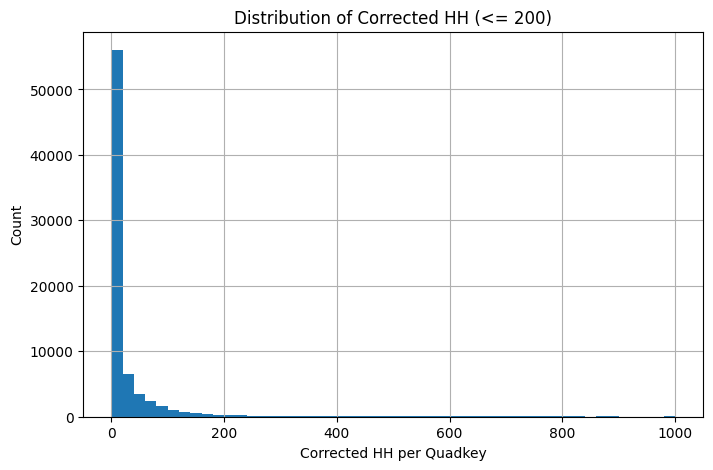

In [ ]:
import matplotlib.pyplot as plt

pdf = (
    three_provinces_plt_w_qgeom
    .filter(col('Qk_estimated_hh_corrected') <= 1000)
    .select('Qk_estimated_hh_corrected')
    .toPandas()
)

plt.figure(figsize=(8, 5))
pdf['Qk_estimated_hh_corrected'].hist(bins=50)
plt.xlabel("Corrected HH per Quadkey")
plt.ylabel("Count")
plt.title("Distribution of Corrected HH (<= 200)")
plt.show()


In [ ]:
quadkey_buil_floor_area = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Gee_Buildings/quadkey_buildings_metric.parquet")
quadkey_buil_floor_area.show()
# quadkey_buil_floor_area.show()

+----------------+------------------+
|         quadkey|sum_floor_area_sqm|
+----------------+------------------+
|1322033120122113|100056.45581796806|
|1322211021222022| 2953.048067602645|
|1322211021220332| 7824.345823513501|
|1322033111301002|2697.3318755100736|
|1322033102122203|  8171.11646373023|
|1322210331303000| 998.1696580793044|
|1322210331123311| 676.6742507127601|
|1322210331311201|1092.1874831596037|
|1322033013133012|29642.815373437632|
|1322121221120001|  13437.2317539232|
|1322121221102101| 99.47995953746475|
|1322120031132111| 7316.238936479892|
|1322120031131222| 82.05562800116735|
|1322120120002310|1199.7106587154765|
|1322102211003101|16538.894804628417|
|1322102211012233|144.90870909072186|
|1322102211012120| 74.40934035080141|
|1322013020221233|111.97675259875146|
|1322013020232101| 2158.948454634184|
|1322213123001023|2396.3169982943014|
+----------------+------------------+
only showing top 20 rows



In [ ]:
bangkok_geom = quadtile_w_subdistrict.filter(col('adm1_name') == 'bangkok').select(col('quadkey'), col('quadkey_geometry'))
bangkok_geom_final = bangkok_geom.join(
    quadkey_buil_floor_area,
    on = 'quadkey',
    how = 'inner'
)
bangkok_geom_final.toPandas().to_csv('bangkok_sum_floor_area.csv', index=False)

[Stage 1133:=====================================================>(98 + 1) / 99]

## Quality checks

In [ ]:
from utils import *
from pyspark.sql.functions import *
from pyspark.sql.window import *

spark = instantiate_spark_sedona("10g")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/05 05:20:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/05 05:20:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Session and SedonaContext have been successfully initiated.


In [27]:
buil = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Gee_Buildings/buildings_full_dataset_with_quadkey_with_floor_area.parquet")
buil = buil.withColumn('quadkey', concat(lit("_"), col("quadkey")))
buil.show()

+-------+--------------------+------------+-----------+-----------+------------+-----------------+------+----------+------------------+------------------+
|     id|       geom_source_1|height_tiles|province_en|district_en|   tambon_en|          quadkey|floors|households| building_area_sqm|  total_floor_area|
+-------+--------------------+------------+-----------+-----------+------------+-----------------+------+----------+------------------+------------------+
|4664436|POLYGON ((100.469...|        NULL|    Bangkok|Bangkok Noi|Arun Ammarin|_1322033101132021|   3.0|         6|29.148552232041453| 87.44565669612436|
|4688642|POLYGON ((100.471...|    HBET:1-5|    Bangkok|Bangkok Noi|Arun Ammarin|_1322033101132032|   3.0|         6|168.23701361735215|504.71104085205644|
|4699077|POLYGON ((100.472...|    HBET:1-5|    Bangkok|Bangkok Noi|Arun Ammarin|_1322033101132032|   3.0|         6|  70.4121949765422| 211.2365849296266|
|4760579|POLYGON ((100.476...|    HBET:1-5|    Bangkok|Bangkok Noi|Aru

In [28]:
buil_grouped = buil.groupBy(col('quadkey')).agg(sum('floors'))
buil_grouped.show()

+-----------------+-----------+
|          quadkey|sum(floors)|
+-----------------+-----------+
|_1322033133211303|      528.0|
|_1322033133211103|     1056.0|
|_1322013001210021|       51.0|
|_1322031330233001|      178.0|
|_1322302200132231|        2.0|
|_1322103230022203|       67.0|
|_1322013330221223|       16.0|
|_1322013330223230|        6.0|
|_1322013330200200|        4.0|
|_1322013330222200|        4.0|
|_1322013332002023|        1.0|
|_1322120222230130|       14.0|
|_1322213010323130|       73.0|
|_1322213010333321|        5.0|
|_1322213010331322|        3.0|
|_1322213012110033|        1.0|
|_1322031332002221|      200.0|
|_1322211203332233|       12.0|
|_1322033101023113|      633.0|
|_1322033111203311|       53.0|
+-----------------+-----------+
only showing top 20 rows



In [32]:
hh_df = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/Quadkey_pop_hh_estimated_updated")
hh_df = hh_df.withColumn('quadkey', concat(lit("_"), col("quadkey")))
hh_df.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- Pop_nso_to_hdx_ratio: double (nullable = true)
 |-- hdx_Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh_sampled: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)



In [34]:
hh_df = hh_df.select(col('quadkey'), col('Qk_estimated_hh'), col('nso_adjusted_population'))
join = buil_grouped.join(
    hh_df,
    on = 'quadkey',
    how = 'inner'

)
join.count()

981682

In [35]:
join = join.withColumn("% higher HH", (col('Qk_estimated_hh') - col('sum(floors)'))*100/col('sum(floors)'))
join.show()

+-----------------+-----------+---------------+-----------------------+------------------+
|          quadkey|sum(floors)|Qk_estimated_hh|nso_adjusted_population|       % higher HH|
+-----------------+-----------+---------------+-----------------------+------------------+
|_1322010330333311|        9.0|            2.0|      4.590031058358725|-77.77777777777777|
|_1322010331222122|        1.0|            1.0|      4.590031058358725|               0.0|
|_1322010332033033|        2.0|            1.0|     1.8581324335677012|             -50.0|
|_1322010332101313|        2.0|            1.0|     3.7162648671354024|             -50.0|
|_1322010332111203|       22.0|            1.0|     3.7162648671354024|-95.45454545454545|
|_1322010332120232|        1.0|            1.0|     2.4775099114236014|               0.0|
|_1322010332131302|        1.0|            2.0|      7.432529734270805|             100.0|
|_1322010332132330|        1.0|            3.0|      9.290662167838505|             200.0|

In [36]:
filtered_join = join.filter(col('% higher HH') > 0)
filtered_join.count()

134844

In [37]:
filtered_join.orderBy(col('% higher HH').desc()).show(10)

+-----------------+-----------+---------------+-----------------------+-----------+
|          quadkey|sum(floors)|Qk_estimated_hh|nso_adjusted_population|% higher HH|
+-----------------+-----------+---------------+-----------------------+-----------+
|_1322102201003320|        1.0|          346.0|     1142.7278370121712|    34500.0|
|_1322122013023003|        1.0|          315.0|      1101.736128946631|    31400.0|
|_1322120010322303|        1.0|          123.0|     422.03797059376956|    12200.0|
|_1322120010320123|        2.0|          123.0|     422.03797059376956|     6050.0|
|_1322031321130133|        2.0|          123.0|      331.2143533200607|     6050.0|
|_1322120010320330|        2.0|          122.0|     422.03797059376956|     6000.0|
|_1322120201022023|        1.0|           49.0|     141.15736239586403|     4800.0|
|_1322121032021300|        2.0|           93.0|     335.22411235560986|     4550.0|
|_1322302230020110|        1.0|           46.0|      173.0861248622639|     

In [38]:
filtered_join.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- sum(floors): double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- % higher HH: double (nullable = true)



In [41]:
from shapely.geometry import shape
import mercantile
def quadkey_to_wkt(qk):
    if not qk:
        return None
    try:

        tile_feature = mercantile.feature(mercantile.quadkey_to_tile(qk))
        return shape(tile_feature['geometry']).wkt
    except:
        return None
quadkey_to_wkt_udf = udf(quadkey_to_wkt, StringType())

filtered_join = filtered_join.withColumn('geometry', quadkey_to_wkt_udf(substring(col('quadkey'), 2, 16)))
filtered_join.show()

+-----------------+-----------+---------------+-----------------------+------------------+--------------------+
|          quadkey|sum(floors)|Qk_estimated_hh|nso_adjusted_population|       % higher HH|            geometry|
+-----------------+-----------+---------------+-----------------------+------------------+--------------------+
|_1322010332131302|        1.0|            2.0|      7.432529734270805|             100.0|POLYGON ((98.0639...|
|_1322010332132330|        1.0|            3.0|      9.290662167838505|             200.0|POLYGON ((98.0310...|
|_1322010332310031|        1.0|            2.0|      7.432529734270805|             100.0|POLYGON ((98.0145...|
|_1322010333020213|        1.0|            2.0|      7.432529734270805|             100.0|POLYGON ((98.1024...|
|_1322010333101102|        1.0|            2.0|     6.8850465875380875|             100.0|POLYGON ((98.3276...|
|_1322011203333022|        3.0|            5.0|     14.435223637535163| 66.66666666666667|POLYGON ((99.0

In [42]:

filtered_join.orderBy(col('% higher HH').desc()).show(100)

+-----------------+-----------+---------------+-----------------------+------------------+--------------------+
|          quadkey|sum(floors)|Qk_estimated_hh|nso_adjusted_population|       % higher HH|            geometry|
+-----------------+-----------+---------------+-----------------------+------------------+--------------------+
|_1322102201003320|        1.0|          346.0|     1142.7278370121712|           34500.0|POLYGON ((101.667...|
|_1322122013023003|        1.0|          315.0|      1101.736128946631|           31400.0|POLYGON ((102.354...|
|_1322120010322303|        1.0|          123.0|     422.03797059376956|           12200.0|POLYGON ((102.156...|
|_1322031321130133|        2.0|          123.0|      331.2143533200607|            6050.0|POLYGON ((100.497...|
|_1322120010320123|        2.0|          123.0|     422.03797059376956|            6050.0|POLYGON ((102.156...|
|_1322120010320330|        2.0|          122.0|     422.03797059376956|            6000.0|POLYGON ((102.

In [45]:
filtered_join_plottable = buil.join(
    filtered_join,
    on = 'quadkey',
    how = 'inner'
)
filtered_join_plottable.show()

+-----------------+--------+--------------------+------------+------------+-------------------+--------------+------+----------+------------------+------------------+-----------+---------------+-----------------------+------------------+--------------------+
|          quadkey|      id|       geom_source_1|height_tiles| province_en|        district_en|     tambon_en|floors|households| building_area_sqm|  total_floor_area|sum(floors)|Qk_estimated_hh|nso_adjusted_population|       % higher HH|            geometry|
+-----------------+--------+--------------------+------------+------------+-------------------+--------------+------+----------+------------------+------------------+-----------+---------------+-----------------------+------------------+--------------------+
|_1322010332131302|26012585|POLYGON ((98.0658...|        NULL|Mae Hong Son|Mueang Mae Hong Son|      Huai Pha|   1.0|         1|  61.8884040690133|  61.8884040690133|        1.0|            2.0|      7.432529734270805|     

In [46]:
filtered_join_plottable.orderBy(col('% higher HH').desc()).toPandas().head(300).to_csv('buildings_abnormal.csv', index=False)

In [39]:
filtered_join.orderBy(col('% higher HH').desc()).toPandas().head(300).to_csv('check.csv', index=False)